Feller Ratio: 9.967960128159486


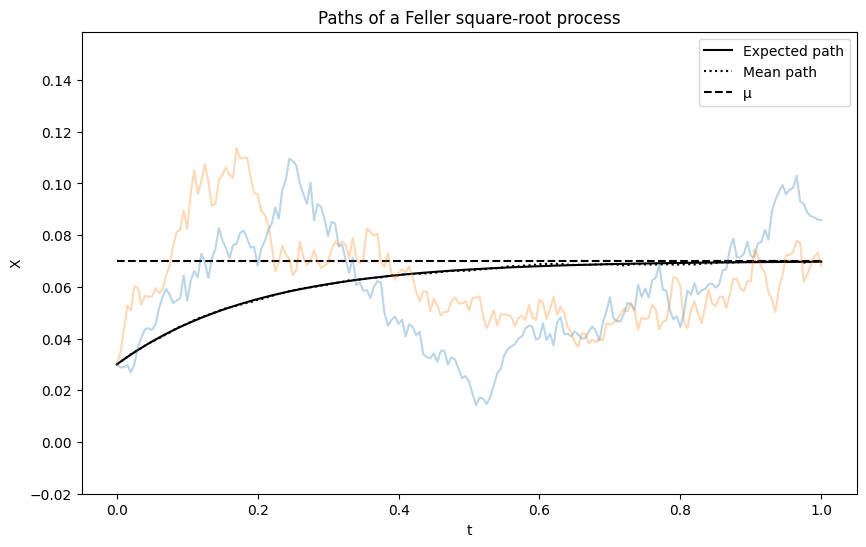

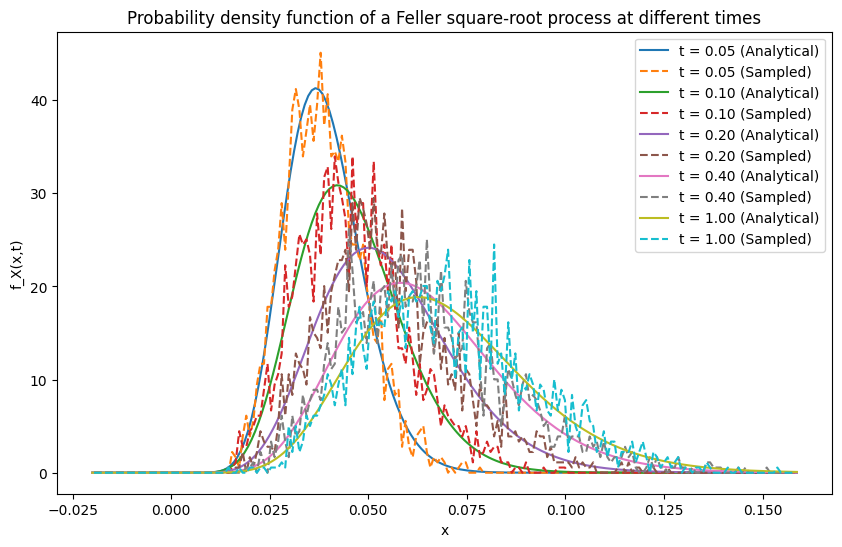

In [179]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ncx2

# Monte Carlo simulation of the Feller square-root process
# dX = alpha*(mu-X)*dt + sigma*sqrt(X)*dW

# Define parameters and time grid
npaths = 2000  # number of paths
T = 1  # time horizon
nsteps = 200  # number of time steps
dt = T / nsteps  # time step
t = np.linspace(0, T, nsteps + 1)  # observation times
alpha, mu, sigma = 5, 0.07, 0.265  # model parameters
X0 = 0.03  # initial value

# Feller ratio for monitoring
Feller_ratio = 2 * alpha * mu / sigma**2
print(f"Feller Ratio: {Feller_ratio}")

# Monte Carlo simulation
# Allocate and initialize all paths
X = np.zeros((nsteps + 1, npaths))
X[0, :] = X0

# Generate standard normal random numbers
N = np.random.randn(nsteps, npaths)

# Calculate coefficients for the Euler-Maruyama method with analytic moments
a = sigma**2 / alpha * (np.exp(-alpha * dt) - np.exp(-2 * alpha * dt))
b = mu * sigma**2 / (2 * alpha) * (1 - np.exp(-alpha * dt))**2

# Compute and accumulate the increments
for i in range(nsteps):
    X[i + 1, :] = (
        mu + (X[i, :] - mu) * np.exp(-alpha * dt)
        + np.sqrt(np.maximum(0, a * X[i, :] + b)) * N[i, :]
    )
    X[i + 1, :] = np.maximum(X[i + 1, :], 0)  # Ensure non-negativity

# Expected, mean, and sample paths
plt.figure(figsize=(10, 6))
EX = mu + (X0 - mu) * np.exp(-alpha * t)  # expected path
plt.plot(t, EX, 'k', label='Expected path')
plt.plot(t, np.mean(X, axis=1), ':k', label='Mean path')
plt.plot(t, mu * np.ones_like(t), 'k--', label='μ')
plt.plot(t, X[:, ::1000], alpha=0.3)
plt.xlabel('t')
plt.ylabel('X')
plt.legend()
plt.title('Paths of a Feller square-root process')
sdev_infty = sigma * np.sqrt(mu / (2 * alpha))
plt.ylim([-0.02, mu + 4 * sdev_infty])
plt.savefig('fsrppaths.png')
plt.show()

# Probability density function at different times
t2 = [0.05, 0.1, 0.2, 0.4, 1]
x = np.linspace(-0.02, mu + 4 * sdev_infty, 200)

k = sigma**2 * (1 - np.exp(-alpha * np.array(t2))) / (4 * alpha)
d = 4 * alpha * mu / sigma**2
lambda_param = 4 * alpha * X0 / (sigma**2 * (np.exp(alpha * np.array(t2)) - 1))

fa = np.zeros((len(x), len(t2)))  # analytical
fs = np.zeros((len(x) - 1, len(t2)))  # sampled (adjusted for histogram bin count)

for i, t_val in enumerate(t2):
    # Analytical PDF using the non-central chi-square distribution
    fa[:, i] = ncx2.pdf(x / k[i], d, lambda_param[i]) / k[i]
    # Sampled PDF using histogram
    hist, bin_edges = np.histogram(X[int(t_val * nsteps), :], bins=x, density=True)
    fs[:, i] = hist  # Histogram values match the size len(x) - 1

# Adjust x to match histogram midpoints for plotting sampled data
x_midpoints = (x[:-1] + x[1:]) / 2

plt.figure(figsize=(10, 6))
for i, t_val in enumerate(t2):
    plt.plot(x, fa[:, i], label=f't = {t_val:.2f} (Analytical)')
    plt.plot(x_midpoints, fs[:, i], '--', label=f't = {t_val:.2f} (Sampled)')

plt.xlabel('x')
plt.ylabel('f_X(x,t)')
plt.legend()
plt.title('Probability density function of a Feller square-root process at different times')
plt.savefig('fsrpdensities.png')
plt.show()